In [1]:
import os
from pathlib import Path

# Asegurar que el kernel corre desde notebooks/ para que ../data y ../outputs funcionen
_cwd = Path.cwd()
if _cwd.name != "notebooks":
    _nb_dir = _cwd / "notebooks"
    if _nb_dir.is_dir():
        os.chdir(_nb_dir)

# Crear directorios si no existen
for _d in ["../outputs", "../data", "../models"]:
    Path(_d).mkdir(exist_ok=True)

print(f"cwd: {Path.cwd()}")

cwd: c:\Users\adria\OneDrive\Desktop\Proyecto de machine learning\notebooks


# Fase 1 — Exploración de Precios de Acciones

En este notebook descargamos precios históricos de acciones usando `yfinance` y analizamos cómo se mueve el precio alrededor de las fechas de earnings calls.

**Objetivo:** Para cada earnings call, calcular el movimiento de precio en las 24-48hs posteriores. Eso será nuestra **variable objetivo** (lo que el modelo va a predecir).

## 1. Importar librerías

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Descargar precios históricos

`yfinance` nos permite descargar el historial de precios de cualquier empresa usando su **ticker** (el símbolo bursátil).

Ejemplos de tickers:
- `AAPL` → Apple
- `MSFT` → Microsoft  
- `GOOGL` → Google
- `META` → Meta (Facebook)

El resultado es un DataFrame de pandas con columnas: Open, High, Low, Close, Volume.

In [3]:
import tempfile

tickers = ['AAPL', 'MSFT', 'GOOGL', 'META', 'NFLX', 'TSLA', 'AMZN', 'NVDA', 'AMD', 'JPM', 'V', 'MA']

# Usamos un directorio temporal para evitar el error "database is locked"
yf.set_tz_cache_location(tempfile.mkdtemp())

precios = yf.download(
    tickers=tickers,
    start='2019-01-01',
    end='2024-12-31',
    auto_adjust=True,
    progress=True
)

cobertura = precios['Close'].notna().sum()
print(f'Shape del dataset: {precios.shape}')
print(f'Fechas: {precios.index[0].date()} → {precios.index[-1].date()}')
print(f'\nDías con datos por ticker:')
print(cobertura)
precios['Close'].tail(3)

[*********************100%***********************]  12 of 12 completed


Shape del dataset: (1509, 60)
Fechas: 2019-01-02 → 2024-12-30

Días con datos por ticker:
Ticker
AAPL     1509
AMD      1509
AMZN     1509
GOOGL    1509
JPM      1509
MA       1509
META     1509
MSFT     1509
NFLX     1509
NVDA     1509
TSLA     1509
V        1509
dtype: int64


Ticker,AAPL,AMD,AMZN,GOOGL,JPM,MA,META,MSFT,NFLX,NVDA,TSLA,V
Date,,,,,,,,,,,,
2024-12-26,257.612732,125.059998,227.050003,194.699875,235.823608,531.374451,600.938843,433.911438,92.414001,139.884171,454.130005,317.991058
2024-12-27,254.201385,125.190002,223.750000,191.872940,233.912888,527.459595,597.413025,426.404083,90.754997,136.965118,431.660004,315.761536
2024-12-30,250.829803,122.440002,221.300003,190.359955,232.118561,520.868835,588.877258,420.758698,90.042999,137.444946,417.410004,312.441986


## 3. Fechas de earnings calls

Cargamos las fechas reales de earnings calls. Estas fechas son públicas — cada empresa las anuncia con anticipación y quedan registradas en sitios como macrotrends.net.

Más adelante estas fechas vendrán automáticamente del dataset de transcripciones.

In [4]:
earnings_dates = {
    'AAPL': [
        '2020-01-28', '2020-04-30', '2020-07-30', '2020-10-29',
        '2021-01-27', '2021-04-28', '2021-07-27', '2021-10-28',
        '2022-01-27', '2022-04-28', '2022-07-28', '2022-10-27',
        '2023-02-02', '2023-05-04', '2023-08-03', '2023-11-02',
        '2024-02-01', '2024-05-02', '2024-08-01', '2024-10-31',
    ],
    'MSFT': [
        '2020-01-29', '2020-04-29', '2020-07-22', '2020-10-28',
        '2021-01-26', '2021-04-27', '2021-07-27', '2021-10-26',
        '2022-01-25', '2022-04-26', '2022-07-26', '2022-10-25',
        '2023-01-24', '2023-04-25', '2023-07-25', '2023-10-24',
        '2024-01-30', '2024-04-25', '2024-07-30', '2024-10-30',
    ],
    'GOOGL': [
        '2020-04-28', '2020-07-28', '2020-10-29', '2021-02-02',
        '2021-04-27', '2021-07-27', '2021-10-26', '2022-02-01',
        '2022-04-26', '2022-07-26', '2022-10-25', '2023-02-02',
        '2023-04-25', '2023-07-25', '2023-10-24',
        '2024-01-30', '2024-04-25', '2024-07-23', '2024-10-29',
    ],
    'META': [
        '2020-04-29', '2020-07-29', '2020-10-29', '2021-01-27',
        '2021-04-28', '2021-07-28', '2021-10-25', '2022-02-02',
        '2022-04-27', '2022-07-27', '2022-10-26', '2023-02-01',
        '2023-04-26', '2023-07-26', '2023-10-25',
        '2024-01-31', '2024-04-24', '2024-07-31', '2024-10-30',
    ],
    'NFLX': [
        '2020-04-21', '2020-07-16', '2020-10-20', '2021-01-19',
        '2021-04-20', '2021-07-20', '2021-10-19', '2022-01-20',
        '2022-04-19',  # Q1 2022: perdió suscriptores por primera vez, -35%
        '2022-07-19', '2022-10-18', '2023-01-19',
        '2023-04-18', '2023-07-19', '2023-10-18',
        '2024-01-23', '2024-04-18', '2024-07-17', '2024-10-16',
    ],
    'TSLA': [
        '2019-07-24', '2019-10-23',
        '2020-01-29', '2020-04-29', '2020-10-21',
        '2021-01-27', '2021-04-26', '2021-07-26', '2021-10-20',
        '2022-01-26', '2022-04-20', '2022-07-20', '2022-10-19',
        '2023-01-25', '2023-04-19', '2023-07-19', '2023-10-18',
        '2024-01-24', '2024-04-23', '2024-07-23', '2024-10-23',
    ],
    'AMZN': [
        '2019-01-31',
        '2020-04-30', '2020-07-30', '2020-10-29',
        '2021-02-04', '2021-04-29', '2021-08-05', '2021-10-28',
        '2022-02-03', '2022-04-28', '2022-07-28', '2022-10-27',
        '2023-02-02', '2023-04-27', '2023-08-03', '2023-10-26',
        '2024-02-01', '2024-05-02', '2024-08-01', '2024-10-31',
    ],
    'NVDA': [
        '2019-08-15', '2019-11-14',
        '2020-02-13', '2020-05-21', '2020-08-19', '2020-11-18',
        '2021-02-24', '2021-05-26', '2021-08-25', '2021-11-17',
        '2022-02-16', '2022-05-25', '2022-08-24', '2022-11-16',
        '2023-02-22', '2023-05-24', '2023-08-23', '2023-11-21',
        '2024-02-21', '2024-05-22', '2024-08-28',
    ],
    'AMD': [
        '2020-10-27',
        '2021-01-26', '2021-04-27', '2021-07-27', '2021-10-26',
        '2022-02-01', '2022-05-03', '2022-08-02', '2022-11-01',
        '2023-01-31', '2023-04-25', '2023-08-01', '2023-10-31',
        '2024-01-30', '2024-04-30', '2024-07-30', '2024-10-29',
    ],
    'JPM': [
        '2020-10-13',
        '2021-01-15', '2021-04-14', '2021-07-13', '2021-10-13',
        '2022-01-14', '2022-04-13', '2022-07-14', '2022-10-14',
        '2023-01-13', '2023-04-14', '2023-07-14', '2023-10-13',
        '2024-01-12', '2024-04-12', '2024-07-12', '2024-10-11',
    ],
    'V': [
        '2020-04-30', '2020-07-28', '2020-10-28',
        '2021-01-28', '2021-04-28', '2021-07-27', '2021-10-26',
        '2022-01-27', '2022-04-26', '2022-07-26', '2022-10-25',
        '2023-01-26', '2023-04-25', '2023-07-25', '2023-10-24',
        '2024-01-23', '2024-04-23', '2024-07-23', '2024-10-22',
    ],
    'MA': [
        '2020-10-28',
        '2021-01-28', '2021-04-29', '2021-07-29', '2021-10-28',
        '2022-01-27', '2022-04-26', '2022-07-26', '2022-10-27',
        '2023-01-26', '2023-04-25', '2023-07-25', '2023-10-25',
        '2024-01-25', '2024-04-29', '2024-07-25', '2024-10-29',
    ],
}

print(f'Empresas: {list(earnings_dates.keys())}')
total = sum(len(v) for v in earnings_dates.values())
print(f'Earnings por empresa: {[(k, len(v)) for k, v in earnings_dates.items()]}')
print(f'Total de earnings calls: {total}')

Empresas: ['AAPL', 'MSFT', 'GOOGL', 'META', 'NFLX', 'TSLA', 'AMZN', 'NVDA', 'AMD', 'JPM', 'V', 'MA']
Earnings por empresa: [('AAPL', 20), ('MSFT', 20), ('GOOGL', 19), ('META', 19), ('NFLX', 19), ('TSLA', 21), ('AMZN', 20), ('NVDA', 21), ('AMD', 17), ('JPM', 17), ('V', 19), ('MA', 17)]
Total de earnings calls: 229


## 4. Calcular el movimiento de precio post-earnings

Para cada earnings call calculamos el retorno porcentual:

$$\text{retorno} = \frac{\text{precio}_{t+1} - \text{precio}_{t-1}}{\text{precio}_{t-1}} \times 100$$

- $t-1$ = cierre del día anterior al earnings (lo que el mercado ya sabía)
- $t+1$ = cierre del día siguiente (cómo reaccionó el mercado)

Si el resultado es positivo → la acción subió. Si es negativo → bajó. Esto va a ser nuestra **variable objetivo** en el modelo de ML.

In [5]:
def calcular_retorno_post_earnings(ticker, fecha_earnings, precios_df, dias_ventana=1):
    fecha = pd.Timestamp(fecha_earnings)
    try:
        closes = precios_df['Close'][ticker]
    except KeyError:
        return None

    idx = closes.index.searchsorted(fecha)

    # Necesitamos al menos 21 días previos para calcular momentum_20d
    if idx < 21 or idx + dias_ventana >= len(closes):
        return None

    precio_antes   = closes.iloc[idx - 1]
    precio_despues = closes.iloc[idx + dias_ventana]
    retorno_pct    = ((precio_despues - precio_antes) / precio_antes) * 100

    # Momentum pre-earnings: retorno acumulado en los N días previos
    momentum_5d  = ((closes.iloc[idx - 1] / closes.iloc[idx - 6])  - 1) * 100
    momentum_20d = ((closes.iloc[idx - 1] / closes.iloc[idx - 21]) - 1) * 100

    # Volatilidad pre-earnings: desvío estándar de retornos diarios (20 días)
    returns_20d    = closes.iloc[idx - 20:idx].pct_change().dropna()
    volatility_20d = float(returns_20d.std() * 100)

    return {
        'ticker':         ticker,
        'fecha_earnings': fecha_earnings,
        'precio_antes':   round(float(precio_antes),   2),
        'precio_despues': round(float(precio_despues), 2),
        'retorno_pct':    round(float(retorno_pct),    2),
        'direccion':      'SUBE' if retorno_pct > 0 else 'BAJA',
        'momentum_5d':    round(float(momentum_5d),    4),
        'momentum_20d':   round(float(momentum_20d),   4),
        'volatility_20d': round(float(volatility_20d), 4),
    }

resultados = []
for ticker, fechas in earnings_dates.items():
    for fecha in fechas:
        resultado = calcular_retorno_post_earnings(ticker, fecha, precios)
        if resultado:
            resultados.append(resultado)

df_retornos = pd.DataFrame(resultados)
print(f'Earnings calculadas: {len(df_retornos)}')
print(f'Columnas: {list(df_retornos.columns)}')
df_retornos.head()

Earnings calculadas: 228
Columnas: ['ticker', 'fecha_earnings', 'precio_antes', 'precio_despues', 'retorno_pct', 'direccion', 'momentum_5d', 'momentum_20d', 'volatility_20d']


,ticker,fecha_earnings,precio_antes,precio_despues,retorno_pct,direccion,momentum_5d,momentum_20d,volatility_20d
0,AAPL,2020-01-28,74.47,78.18,4.98,SUBE,-3.0684,6.5675,1.3268
1,AAPL,2020-04-30,69.52,69.85,0.47,SUBE,4.2123,13.1503,2.8670
2,AAPL,2020-07-30,92.11,102.98,11.81,SUBE,-2.2951,4.2105,1.7631
3,AAPL,2020-10-29,107.96,105.69,-2.10,BAJA,-4.8516,-3.9807,2.5351
4,AAPL,2021-01-27,139.23,133.33,-4.24,BAJA,11.9925,8.4792,2.1102


## 5. Visualización — Retornos por empresa

Las barras verdes indican que la acción subió post-earnings, las rojas que bajó.

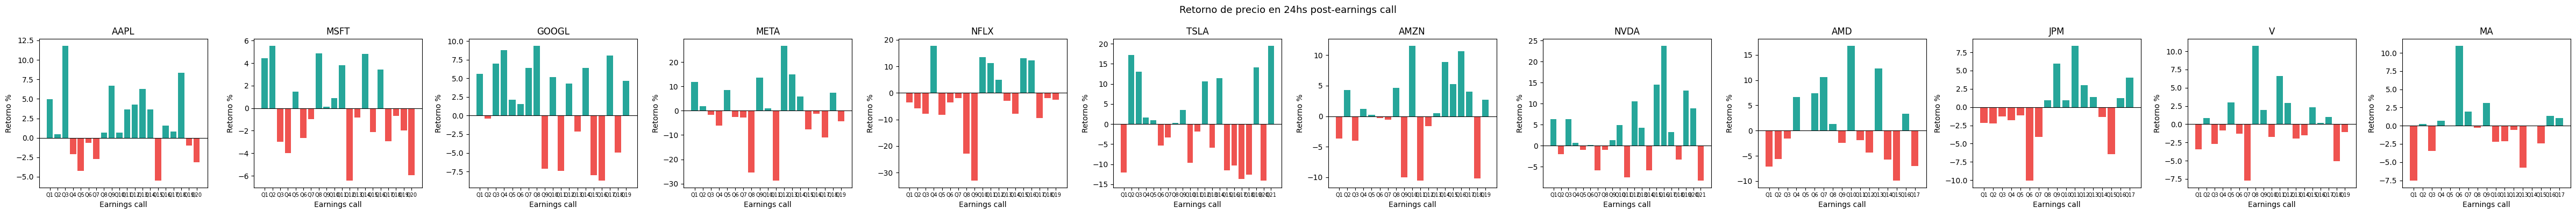

Gráfico guardado en outputs/retornos_earnings.png


In [6]:
tickers_unicos = df_retornos['ticker'].unique()
fig, axes = plt.subplots(1, len(tickers_unicos), figsize=(4 * len(tickers_unicos), 4), sharey=False)

for ax, ticker in zip(axes, tickers_unicos):
    df_t = df_retornos[df_retornos['ticker'] == ticker].copy()
    colores = ['#26a69a' if d == 'SUBE' else '#ef5350' for d in df_t['direccion']]
    ax.bar(range(len(df_t)), df_t['retorno_pct'], color=colores)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(ticker)
    ax.set_xlabel('Earnings call')
    ax.set_ylabel('Retorno %')
    ax.set_xticks(range(len(df_t)))
    ax.set_xticklabels([f"Q{i+1}" for i in range(len(df_t))], fontsize=7)

plt.suptitle('Retorno de precio en 24hs post-earnings call', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/retornos_earnings.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gráfico guardado en outputs/retornos_earnings.png')

## 6. Estadísticas descriptivas

Antes de modelar siempre miramos los números básicos. Esto nos dice si el problema está balanceado (¿hay más subidas que bajadas?) y qué tan grandes son los movimientos típicos.

In [7]:
print('=== Distribución de dirección ===')
print(df_retornos['direccion'].value_counts())
print(f'\nBalance: {df_retornos["direccion"].value_counts(normalize=True).round(2).to_dict()}')

print('\n=== Retorno promedio por empresa ===')
print(df_retornos.groupby('ticker')['retorno_pct'].agg(['mean', 'std', 'min', 'max']).round(2))

print('\n=== Retorno promedio por dirección ===')
print(df_retornos.groupby('direccion')['retorno_pct'].mean().round(2))

=== Distribución de dirección ===
direccion
SUBE    114
BAJA    114
Name: count, dtype: int64

Balance: {'SUBE': 0.5, 'BAJA': 0.5}

=== Retorno promedio por empresa ===
        mean    std    min    max
ticker                           
AAPL    1.72   4.46  -5.50  11.81
AMD     0.76   7.69  -9.94  16.83
AMZN    0.68   6.50 -10.59  11.56
GOOGL   1.61   6.19  -8.74   9.38
JPM    -0.27   4.42 -10.08   8.40
MA     -0.30   3.98  -7.55  10.98
META    0.02  13.26 -28.78  26.72
MSFT   -0.10   3.66  -6.44   5.54
NFLX   -2.09  12.60 -33.05  17.74
NVDA    2.98   8.05  -8.35  23.76
TSLA   -0.40  10.97 -14.12  19.50
V       0.11   4.12  -7.74  10.75

=== Retorno promedio por dirección ===
direccion
BAJA   -5.25
SUBE    6.09
Name: retorno_pct, dtype: float64


## 7. Guardar los datos

Guardamos el resultado para usarlo en los próximos notebooks.

In [8]:
df_retornos.to_csv('../data/retornos_earnings.csv', index=False)
print('Datos guardados en data/retornos_earnings.csv')
print(f'Shape: {df_retornos.shape}')

Datos guardados en data/retornos_earnings.csv
Shape: (228, 9)
